In [15]:
import numpy as np
import matplotlib.pyplot as plt

def build_and_diagonalize_M(N, beta):
    M = np.zeros((N, N))
    beta_sq = beta**2

    if N > 0:
        M[0, 0] = -beta_sq / 12.0
    if N > 1:
        M[1, 1] = -beta_sq / 60.0

    for q in range(N):
        if q >= 2:
            M[q, q] = -beta_sq / (2.0 * (2*q - 1) * (2*q + 3))
        
        if q + 2 < N:
            M[q + 2, q] = beta_sq / (4.0 * (2*q + 1) * (2*q + 3))
        
        if q - 2 >= 0:
            M[q - 2, q] = beta_sq / (4.0 * (2*q - 1) * (2*q + 1))

    eigenvalues, eigenvectors = np.linalg.eig(M)
    
    idx = np.argsort(np.abs(eigenvalues))[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return M, eigenvalues, eigenvectors

N = 5
betas = np.linspace(5, 500, 20)
largest_evals_1 = []
largest_evals_2 = []
largest_evals_3 = []
largest_evals_4 = []
for beta in betas:
    M_matrix, evals, evecs = build_and_diagonalize_M(N, beta)
    largest_evals_1.append(evals[0].real/beta**2)
    largest_evals_2.append(evals[1].real/beta**2)
    largest_evals_3.append(evals[2].real/beta**2)
    largest_evals_4.append(evals[3].real/beta**2)


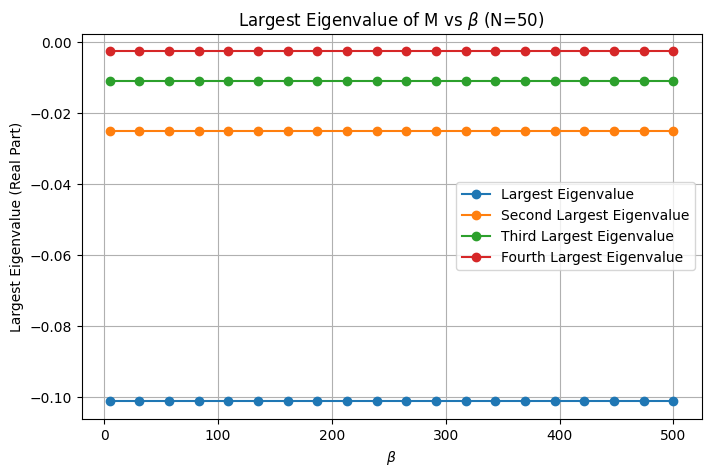

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(betas, largest_evals_1, marker='o', label='Largest Eigenvalue')
plt.plot(betas, largest_evals_2, marker='o', label='Second Largest Eigenvalue')
plt.plot(betas, largest_evals_3, marker='o', label='Third Largest Eigenvalue')
plt.plot(betas, largest_evals_4, marker='o', label='Fourth Largest Eigenvalue')
plt.legend()
plt.xlabel('$\\beta$')
plt.ylabel('Largest Eigenvalue (Real Part)')
plt.title('Largest Eigenvalue of M vs $\\beta$ (N=50)')
plt.grid(True)
plt.show()

In [14]:
print(largest_evals_1)

[np.float64(-2.533028922284356), np.float64(-97.70053937364919), np.float64(-330.4094152948698), np.float64(-700.6596566859465), np.float64(-1208.4512635468782), np.float64(-1853.7842358776672), np.float64(-2636.6585736783113), np.float64(-3557.074276948809), np.float64(-4615.031345689166), np.float64(-5810.529779899366), np.float64(-7143.569579579436), np.float64(-8614.150744729359), np.float64(-10222.273275349151), np.float64(-11967.937171438783), np.float64(-13851.142432998266), np.float64(-15871.88906002761), np.float64(-18030.17705252682), np.float64(-20326.006410495866), np.float64(-22759.377133934777), np.float64(-25330.289222843567)]


In [ ]:
[np.float64(-2.533029591058445), np.float64(-97.70056516869195), np.float64(-330.40950253005866), np.float64(-700.6598416751586), np.float64(-1208.451582603991), np.float64(-1853.7847253165578), np.float64(-2636.6592698128547), np.float64(-3557.075216092887), np.float64(-4615.0325641566615), np.float64(-5810.531314004152), np.float64(-7143.571465635386), np.float64(-8614.153019050338), np.float64(-10222.27597424904), np.float64(-11967.94033123149), np.float64(-13851.14608999764), np.float64(-15871.893250547537), np.float64(-18030.181812881176), np.float64(-20326.011776998505), np.float64(-22759.383142899635), np.float64(-25330.295910584457)]

N_leg = 10 | Max error: 2.16529e+00
N_leg = 20 | Max error: 1.74217e-01
N_leg = 30 | Max error: 5.18071e-03
N_leg = 40 | Max error: 4.98094e-05
N_leg = 50 | Max error: 1.55708e-07
N_leg = 60 | Max error: 1.70062e-10
N_leg = 70 | Max error: 4.17603e-12
N_leg = 80 | Max error: 3.61129e-12
N_leg = 90 | Max error: 3.20923e-12
N_leg = 100 | Max error: 2.87252e-12


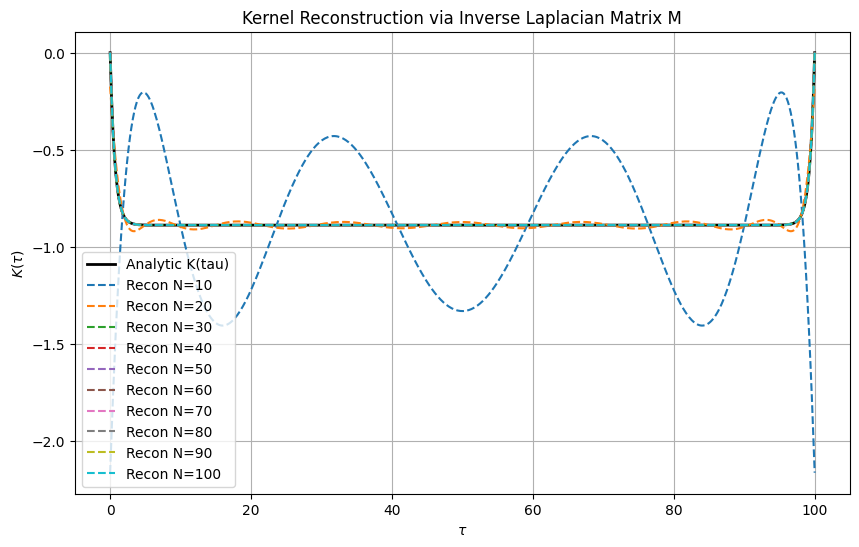

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_legendre

def build_M_matrix(N, beta):
    M = np.zeros((N, N))
    beta_sq = beta**2
    
    if N > 0:
        M[0, 0] = -beta_sq / 12.0
    if N > 1:
        M[1, 1] = -beta_sq / 60.0
        
    for q in range(N):
        if q >= 2:
            M[q, q] = -beta_sq / (2.0 * (2*q - 1) * (2*q + 3))
        if q + 2 < N:
            M[q + 2, q] = beta_sq / (4.0 * (2*q + 1) * (2*q + 3))
        if q - 2 >= 0:
            M[q - 2, q] = beta_sq / (4.0 * (2*q - 1) * (2*q + 1))
            
    return M

beta = 100.0
w0 = 1.5
lam_sq = 2.0

def analytic_D(tau):
    return lam_sq * np.cosh(w0 * (tau - beta/2.0)) / np.sinh(w0 * beta / 2.0)

def analytic_K(tau):
    return (lam_sq / w0**2) * (np.cosh(w0 * (tau - beta/2.0)) / np.sinh(w0 * beta / 2.0) - 1.0 / np.tanh(w0 * beta / 2.0))

x_quad, w_quad = np.polynomial.legendre.leggauss(2000)
tau_quad = (x_quad + 1.0) * beta / 2.0
D_quad = analytic_D(tau_quad)

n_tau = 500
tau_mesh = np.linspace(0, beta, n_tau)
x_mesh = 2.0 * tau_mesh / beta - 1.0
K_exact = analytic_K(tau_mesh)

plt.figure(figsize=(10, 6))
plt.plot(tau_mesh, K_exact, 'k-', linewidth=2, label='Analytic K(tau)')

N_legs = np.linspace(10, 100, 10, dtype=int)
for N_leg in N_legs:
    d_n = np.zeros(N_leg)
    for n in range(N_leg):
        P_n_val = eval_legendre(n, x_quad)
        d_n[n] = (2 * n + 1) / 2.0 * np.sum(w_quad * D_quad * P_n_val)

    M = build_M_matrix(N_leg, beta)

    k_n = M @ d_n

    K_recon = np.zeros(n_tau)
    for n in range(N_leg):
        K_recon += k_n[n] * eval_legendre(n, x_mesh)
    
    max_error = np.max(np.abs(K_recon - K_exact))
    print(f"N_leg = {N_leg:2d} | Max error: {max_error:.5e}")
    
    plt.plot(tau_mesh, K_recon, '--', linewidth=1.5, label=f'Recon N={N_leg}')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$K(\tau)$')
plt.legend()
plt.title('Kernel Reconstruction via Inverse Laplacian Matrix M')
plt.grid(True)
plt.show()